# Training Artificial Neural Network (ANN)

## Preparing the Data

In [2]:
# for google colab to mount google drive
# from google.colab import drive
# drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
import pandas as pd
import numpy as np

In [4]:
# Loading Datasets

root = '..'
# root = '/content/gdrive/MyDrive/Colab Notebooks/car'
# '/content/gdrive/MyDrive/Colab Notebooks/raw/train/df_train.csv'
# '/content/gdrive/MyDrive/Colab Notebooks/raw/train/df_val.csv'
# '../data/train/df_train.csv'
# '../data/train/df_val.csv'

train_csv = f'{root}/data/train/df_train.csv'
val_csv = f'{root}/data/train/df_val.csv'
df_train = pd.read_csv(train_csv)
df_val = pd.read_csv(val_csv)

In [5]:
## Target Variable Processing

In [6]:
'''Target Variable Processing'''

target = 'price'
# Preparing the target Variable:
# The  y dataframes contain the Target Variable for training and validation
y_train = np.log1p(df_train[target])
y_val = np.log1p(df_val[target])

# Remove Target from training and validation datasets
X_train = df_train.drop(columns=target)
X_val = df_val.drop(columns=target)

In [7]:
# Defining column types
numerical = X_train.select_dtypes('number').columns.tolist()
categorical = X_train.select_dtypes(include='object').columns.tolist()
multi_label = [
    'comfort_convenience',
    'entertainment_media',
    'extras',
    'safety_security']

categorical = list(set(categorical)-set(multi_label))
categorical, numerical, multi_label

(['type',
  'fuel',
  'paint_type',
  'body_type',
  'make_model',
  'upholstery_type',
  'drive_chain',
  'vat',
  'gearing_type'],
 ['km',
  'gears',
  'age',
  'previous_owners',
  'hp_kw',
  'inspection_new',
  'displacement_cc',
  'weight_kg',
  'cons_comb'],
 ['comfort_convenience', 'entertainment_media', 'extras', 'safety_security'])

In [8]:
X_train = X_train[categorical + numerical + multi_label]
X_val = X_val[categorical + numerical + multi_label]

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction import DictVectorizer

In [10]:
class FlattenMultiLabelColumns(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Convert each row of the DataFrame into a dictionary;
        # then expand any list columns into multiple {key: 1} entries.
        rows = X.to_dict(orient='records')
        records = []
        for row in rows:
            new_row = {}
            for col, val in row.items():
                if col in multi_label and isinstance(val, list):
                    # For list columns, create new keys col=item
                    for item in val:
                        new_row[f"{col}={item}"] = 1
                else:
                    # For normal columns, just keep the original key/value
                    new_row[col] = val
            records.append(new_row)

        return records

In [11]:
# Apply Standard Scaler to numeric columns
transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical)
    ],
    remainder='passthrough')

transformer.set_output(transform="pandas")

X_train = transformer.fit_transform(X_train)
X_val = transformer.transform(X_val)

In [12]:
X_val.head().T

,0,1,2,3,4
num__km,1.844981,-0.180337,-0.23241,-0.897715,2.6246
num__gears,0.118567,2.99691,0.118567,-1.320604,0.118567
num__age,1.409715,-0.409031,-0.409031,-1.318403,0.500342
num__previous_owners,-0.141924,-0.141924,-0.141924,-0.141924,-0.141924
num__hp_kw,0.993904,1.629311,1.459869,-0.869958,-0.234551
num__inspection_new,1.699427,1.699427,-0.588434,-0.588434,1.699427
num__displacement_cc,2.017321,1.973107,0.256141,-1.552937,0.654065
num__weight_kg,0.316693,1.698808,0.709397,-0.229013,0.306493
num__cons_comb,-0.339152,1.120114,1.606536,-0.217547,-1.555207
remainder__type,used,used,used,new,used


In [13]:
pipeline = Pipeline([
        ('flattern', FlattenMultiLabelColumns()),
        ('vectorizer', DictVectorizer(sparse=False))  # returns dense array
        ])

X_train =(pipeline.fit_transform(X_train))
X_val = pipeline.transform(X_val)

## Training the Neural Net

In [14]:
import tensorflow as tf
from tensorflow import keras

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [15]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

In [16]:
model = Sequential()
model.add(Dense(30, activation='relu', input_shape=(X_train.shape[1], )))
model.add(Dense(1))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 30)                  │         235,890 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              31 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 235,921 (921.57 KB)

 Trainable params: 235,921 (921.57 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss = keras.losses.MeanSquaredError()
rmse = keras.metrics.RootMeanSquaredError()

In [19]:
model.compile(optimizer=optimizer, loss=loss, metrics=[rmse])

In [20]:
history = model.fit(
    X_train,
    y_train,
    batch_size=1024,
    epochs=10,
    verbose=1,
    validation_data=(X_val,y_val)
    )

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 341ms/step - loss: 71.8799 - root_mean_squared_error: 8.4465 - val_loss: 9.0337 - val_root_mean_squared_error: 3.0056
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 4.2394 - root_mean_squared_error: 2.0308 - val_loss: 8.0482 - val_root_mean_squared_error: 2.8369
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 6.7374 - root_mean_squared_error: 2.5712 - val_loss: 0.5371 - val_root_mean_squared_error: 0.7329
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.8713 - root_mean_squared_error: 0.9032 - val_loss: 1.8986 - val_root_mean_squared_error: 1.3779
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7617 - root_mean_squared_error: 0.8586 - val_loss: 0.2418 - val_root_mean_squared_error: 0.4918
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3593 - root_mean_squared_error: 0.5982 - val_loss: 0.1689 - val_root_mean_squared_error: 0.4109
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0702 - ro

In [21]:
import matplotlib.pyplot as plt

def plot_metrics(history):
    # Plot training & validation loss values
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

    # Plot training & validation RMSE values
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['root_mean_squared_error'])
    plt.plot(history.history['val_root_mean_squared_error'])
    plt.title('Model RMSE')
    plt.ylabel('RMSE')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

     # Print the history
    history.history

In [22]:
import pprint
pprint.pp(history.history)

{'loss': [57.510799407958984,
          3.997002124786377,
          4.648514747619629,
          1.2927604913711548,
          0.48458123207092285,
          0.3605790436267853,
          0.07725473493337631,
          0.056686703115701675,
          0.0368431881070137,
          0.017782047390937805],
 'root_mean_squared_error': [7.583587646484375,
                             1.9992504119873047,
                             2.156041383743286,
                             1.1369962692260742,
                             0.6961186528205872,
                             0.6004823446273804,
                             0.277947336435318,
                             0.2380896955728531,
                             0.19194579124450684,
                             0.13334934413433075],
 'val_loss': [9.033748626708984,
              8.048194885253906,
              0.5370959639549255,
              1.8986480236053467,
              0.24183927476406097,
              0.16887041926383972,
 

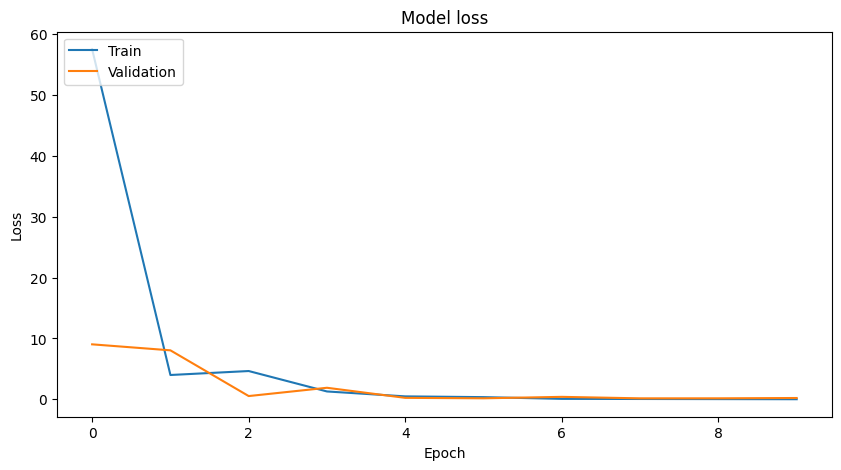

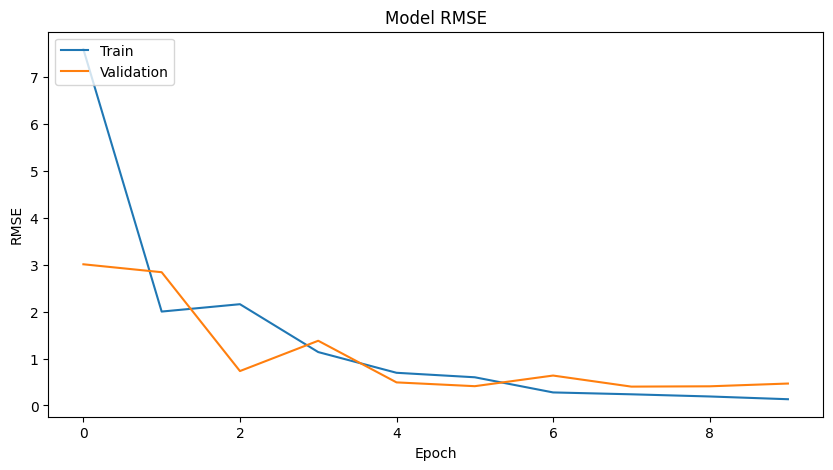

In [23]:
plot_metrics(history)

## Optimization

### Adjusting Learning Rate

In [24]:
scores = {}

for learning_rate in [0.001, 0.01, 0.1, 1.0]:
    print(learning_rate)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=loss, metrics=[rmse])
    history = history = model.fit(
        X_train,
        y_train,
        batch_size=1024,
        epochs=10,
        verbose=1,
        validation_data=(X_val,y_val)
    )
    scores[learning_rate] = history
    print('\n\n')


0.001
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0144 - root_mean_squared_error: 0.3012 - val_loss: 0.1574 - val_root_mean_squared_error: 0.3968
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0116 - root_mean_squared_error: 0.1074 - val_loss: 0.1674 - val_root_mean_squared_error: 0.4091
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0083 - root_mean_squared_error: 0.0911 - val_loss: 0.1887 - val_root_mean_squared_error: 0.4345
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0074 - root_mean_squared_error: 0.0859 - val_loss: 0.1861 - val_root_mean_squared_error: 0.4314
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0069 - root_mean_squared_error: 0.0830 - val_loss: 0.1623 - val_root_mean_squared_error: 0.4028
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0057 - root_mean_squared_error: 0.0755 - val_loss: 0.1497 - val_root_mean_squared_error: 0.3870
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0070


 0.001 



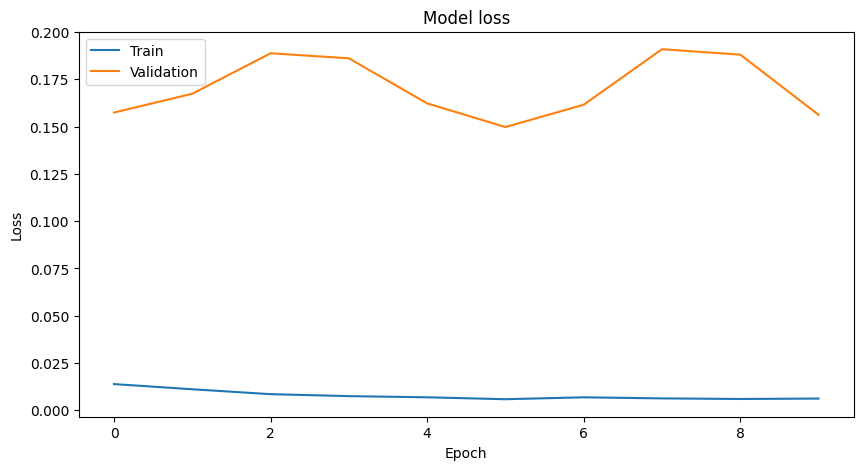

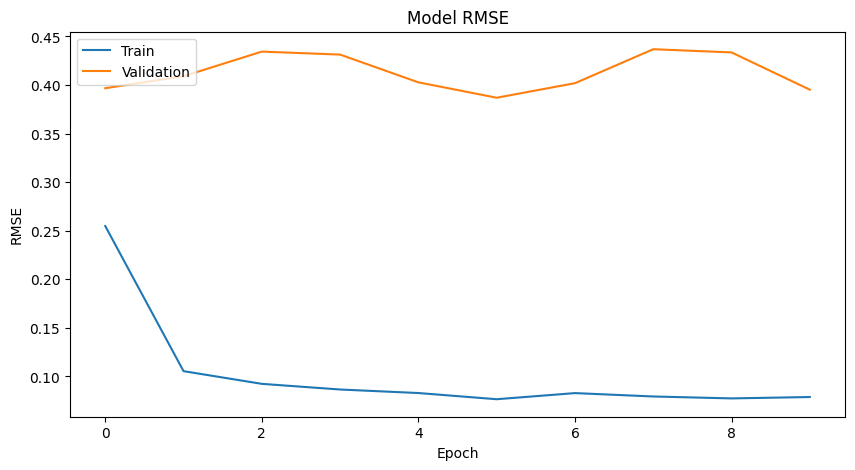


 0.01 



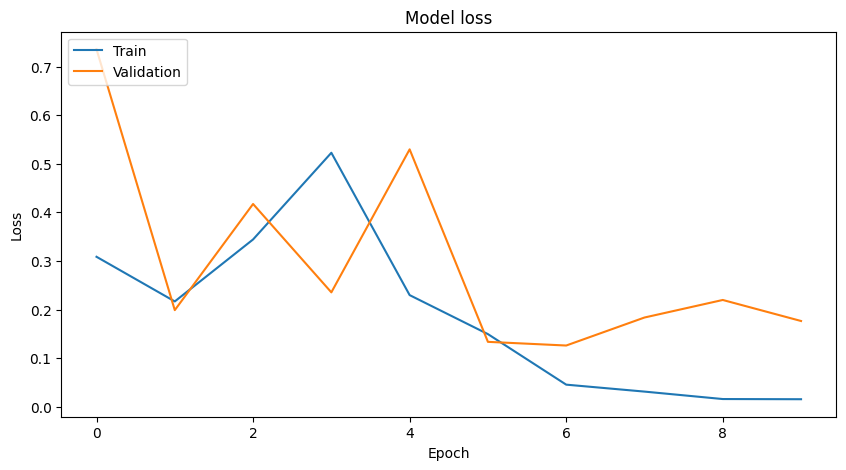

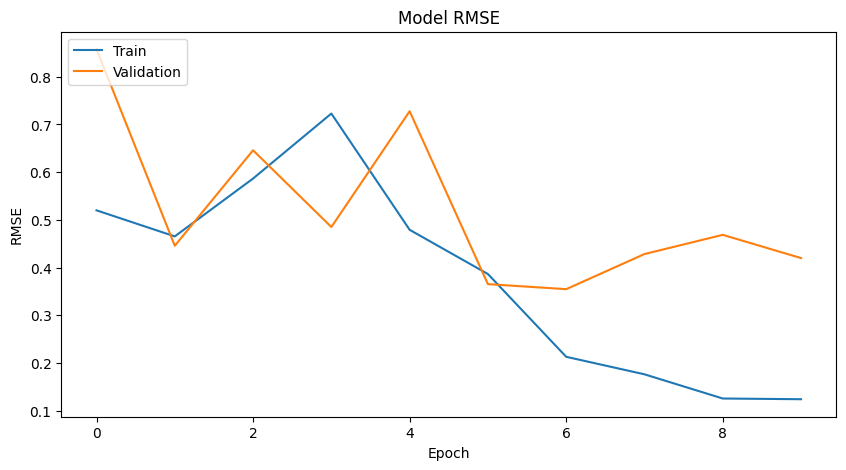


 0.1 



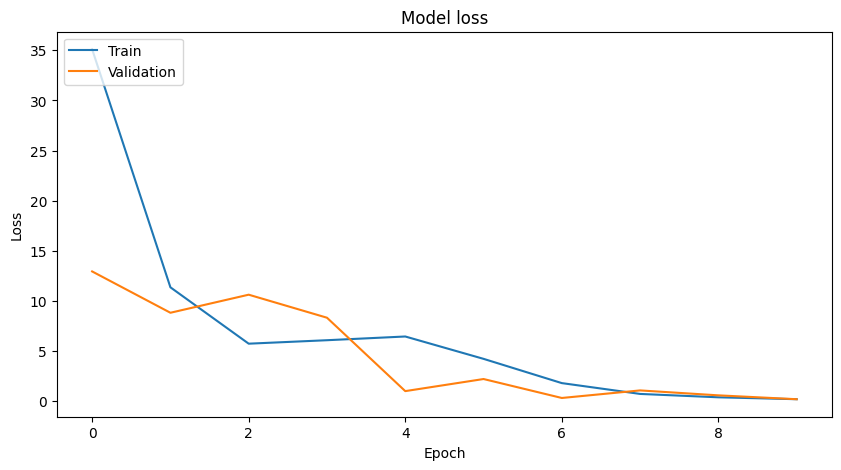

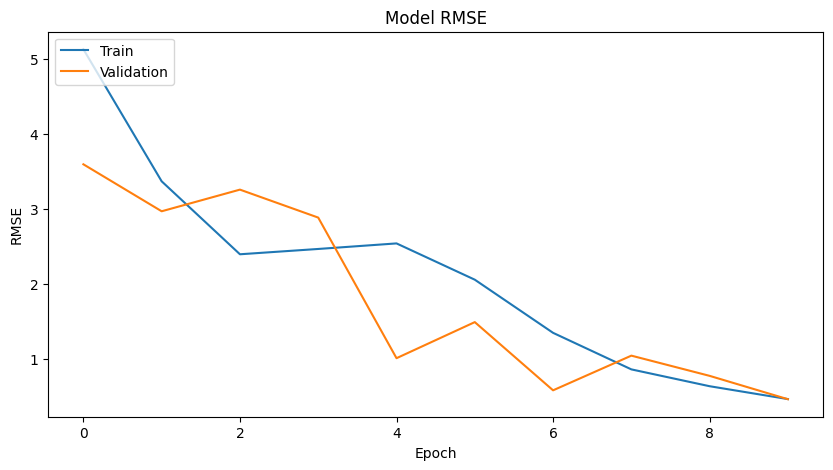


 1.0 



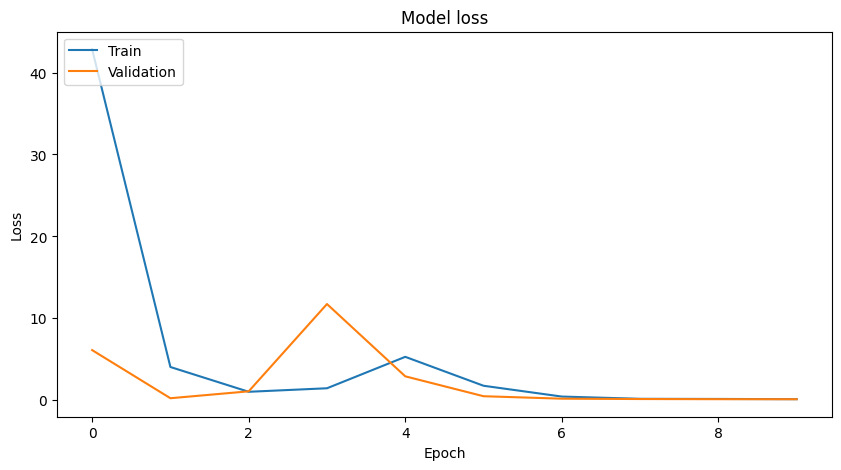

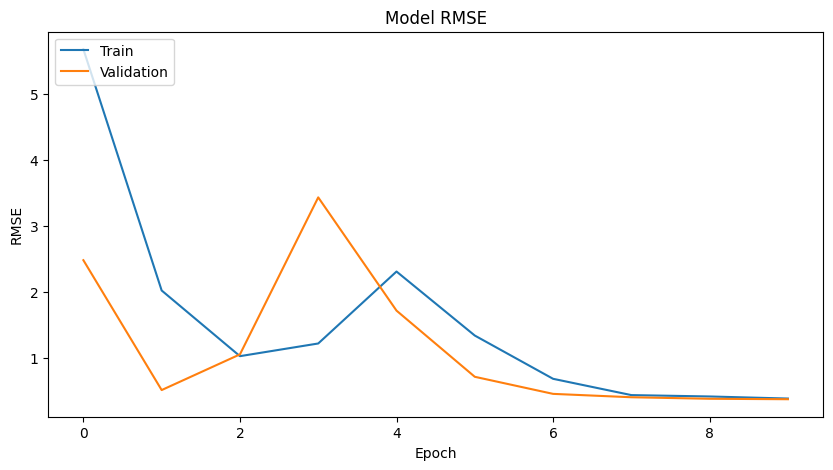

In [25]:

for learning_rate, history in scores.items():
    print(f'\n {learning_rate} \n')
    plot_metrics(history)

### Adding more layers

In [28]:
model = Sequential()
model.add(Dense(64, activation='relu',input_shape=(X_train.shape[1], )))
model.add(Dropout(0.15))
model.add(Dense(128, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss = keras.losses.MeanSquaredError()
rmse = keras.metrics.RootMeanSquaredError()

In [32]:
model.compile(optimizer=optimizer, loss=loss, metrics=[rmse])
model.save('model_v1.keras')

In [33]:
# Adding Checkpoints at which to save the model.
checkpoint = keras.callbacks.ModelCheckpoint(
        'ann_v1_{epoch:02d}_{val_root_mean_squared_error:.3f}.keras',
        save_best_only=True,
        monitor='val_rmse',
        mode='min'
    )

In [35]:
history = model.fit(
        X_train,
        y_train,
        batch_size=4096,
        epochs=50,
        verbose=1,
        validation_data=(X_val,y_val),
        callbacks=[checkpoint]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 93.0426 - root_mean_squared_error: 9.6458 - val_loss: 70.2759 - val_root_mean_squared_error: 8.3831
Epoch 2/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 69.6226 - root_mean_squared_error: 8.3440

/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_rmse available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 59.3501 - root_mean_squared_error: 7.6948 - val_loss: 10.8729 - val_root_mean_squared_error: 3.2974
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 16.4764 - root_mean_squared_error: 4.0524 - val_loss: 1.6967 - val_root_mean_squared_error: 1.3026
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 3.8171 - root_mean_squared_error: 1.9210 - val_loss: 13.7247 - val_root_mean_squared_error: 3.7047
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 11.8336 - root_mean_squared_error: 3.4385 - val_loss: 1.7529 - val_root_mean_squared_error: 1.3240
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 1.4887 - root_mean_squared_error: 1.2193 - val_loss: 3.4447 - val_root_mean_squared_error: 1.8560
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 4.2460 - root_mean_squared_error: 2.0582 - val_loss: 1.0462 - val_root_mean_squared_error: 1.0228
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 1.6752 - root_mean_

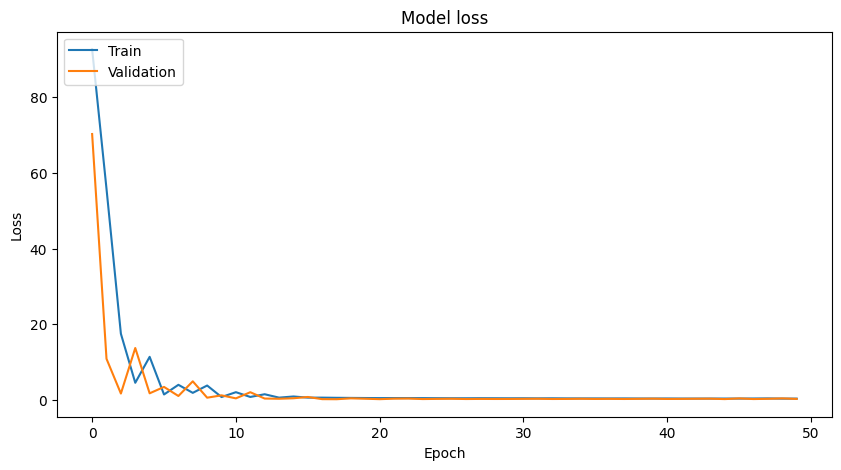

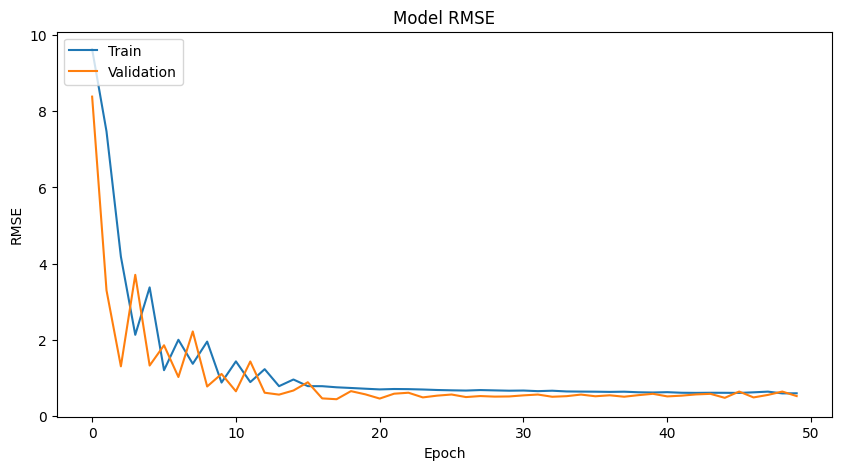

In [36]:
plot_metrics(history)

In [37]:
model.save(f'{root}/models/model_v1.keras')